# Assignment 2: Natural Language Processing 24/25

You are tasked to address the [EDOS Task A](https://github.com/rewire-online/edos) on sexism detection.



*   0001119882 Jana Nikolovska -> jana.nikolovska@studio.unibo.it
*   0001120061 Marco Sangiorgi -> marco.sangiorgi24@studio.unibo.it
*   0001139610 Andrea Fossà -> andrea.fossa@studio.unibo.it  

<br> **Keywords**: Sexism Detection, Multi-class Classification, LLMs, Prompting

In [1]:
!pip install transformers datasets torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [2]:
!pip install -U bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 9.1 MB/s eta 0:00:00


In [34]:
import pandas as pd
import os
from transformers import AutoTokenizer, DataCollatorWithPadding, pipeline
from transformers import AutoModelForCausalLM
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import BitsAndBytesConfig
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random
import csv
import ipywidgets as widgets
from IPython.display import display, HTML

In [4]:
FIGURE_SIZE = (5,5)
COLOR = 'salmon'

## 🤗Huggingface Login

In [5]:
HUGGING_FACE_TOKEN = <INSERT_TOKEN_HERE>

In [6]:
from huggingface_hub import login

login(token=HUGGING_FACE_TOKEN)

## 🧮Read and analyse data

In this section, we will conduct an initial analysis of the dataset. This includes identifying any missing data or inconsistencies, examining the distribution of word lengths per text, and assessing the balance of labels within the dataset.

In [7]:
data_file_path = os.path.join('data', 'a2_test.csv')
demonstrations_file_path = os.path.join('data', 'demonstrations.csv')
label = 'label_sexist'
text = 'text'
label_mapping = {"sexist": 1, "not sexist": 0}

In [55]:
def dataset_overview(df, label=label):
   """
    Displays basic information about the dataset including the first few rows,
    the shape of the dataset, missing values, and class distribution.

    Args:
        df (pandas.DataFrame): The dataset to analyze.
        label (str): The column name for labels in the dataset (default is 'label').
    """
    display(df.head())

    print(f"\n\nDataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

    print("\n\nMissing values:\n", df.isnull().sum())

    label_balance(df, label=label)

def text_length_analysis(df, label=label ,textl=text):
    """
      Analyzes and visualizes the distribution of text lengths in the dataset,
      including a histogram and boxplot for text length by class.

      Args:
          df (pandas.DataFrame): The dataset containing text data.
          label (str): The column name for labels in the dataset (default is 'label').
          textl (str): The column name containing the text data (default is 'text').
    """
    df['text_length'] = df[text].apply(len)
    plt.figure(figsize=FIGURE_SIZE)
    df['text_length'].hist(bins=30,color=COLOR)
    plt.title('Text Length Distribution')
    plt.xlabel('Number of Characters')
    plt.ylabel('Frequency')
    plt.show()

    # Display basic statistics
    print(df['text_length'].describe())

    plt.figure(figsize=FIGURE_SIZE)
    sns.boxplot(data=df, x=label, y='text_length',color=COLOR)
    plt.title('Text Length by Class')
    plt.xlabel('Class')
    plt.ylabel('Text Length')
    plt.show()

def label_balance(df, label=label):
    """
      Visualizes and displays the distribution of class labels in the dataset,
      including a count plot and class proportions.

      Args:
          df (pandas.DataFrame): The dataset to analyze.
          label (str): The column name for labels in the dataset (default is 'label').
    """
    # Visualize class distribution
    plt.figure(figsize=FIGURE_SIZE)
    sns.countplot(data=df, x=label, order=df[label].value_counts().index,color=COLOR)
    plt.title('Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

    # Display class proportions
    print("Class proportions:\n", df[label].value_counts(normalize=True))


def plot_predicted_classes_distribution(data):
    """
      Visualizes the distribution of predicted classes (0 and 1) using a pie chart.

      Args:
          data (list): A list of predicted labels (0 or 1).
    """
    # Count occurrences of 1s and 0s
    counts = [data.count(0), data.count(1)]

    # Labels for the pie chart
    labels = ['Zero (0)', 'One (1)']

    # Create the pie chart
    plt.figure(figsize=FIGURE_SIZE)
    plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
    plt.title('Predicted classes by model distribution')
    plt.show()


def get_confusion_matrix(true_labels, predicted_labels):
    """
      Computes and visualizes the confusion matrix, comparing true and predicted labels.

      Args:
          true_labels (list): The true class labels.
          predicted_labels (list): The predicted class labels.
    """
    # Get the unique classes
    classes = [0,1]

    # Initialize the confusion matrix
    cm = np.zeros((len(classes), len(classes)), dtype=int)

    # Fill the confusion matrix
    for true, pred in zip(true_labels, predicted_labels):
        if true is None or pred is None:
            continue  # Skip cases where true or predicted label is None
        cm[classes.index(true)][classes.index(pred)] += 1

    # Visualize the confusion matrix
    plt.figure(figsize=FIGURE_SIZE)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

def compare_confusion_matrices(true_labels, predictions_list, titles):
    """
      Computes and visualizes multiple confusion matrices for different sets of predictions,
      displaying them in subplots with corresponding titles.

      Args:
          true_labels (list): The true class labels.
          predictions_list (list of lists): A list of predicted label sets.
          titles (list of str): A list of titles for the confusion matrices.
    """
    # Get the unique classes
    classes = [0, 1]

    # Define the number of rows and columns for subplots
    num_plots = len(predictions_list)
    ncols = 4  # Set the max number of plots per row
    nrows = (num_plots // ncols) + (num_plots % ncols > 0)

    # Create a figure with subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i, predictions in enumerate(predictions_list):
        # Initialize the confusion matrix
        cm = np.zeros((len(classes), len(classes)), dtype=int)

        # Fill the confusion matrix
        for true, pred in zip(true_labels, predictions):
            if true is None or pred is None:
                continue  # Skip cases where true or predicted label is None
            cm[classes.index(true)][classes.index(pred)] += 1

        # Plot the confusion matrix on the respective subplot
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes,
                    ax=axes[i], cbar=False)
        axes[i].set_title(f'Confusion Matrix for {titles[i]}')
        axes[i].set_xlabel('Predicted Labels')
        axes[i].set_ylabel('True Labels')

    # Hide any unused axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    # Adjust the layout
    plt.tight_layout()
    plt.show()


def save_dict_to_csv(dictionary, filename):
    """
      Storing intermediate results during long executions - Save a dictionary to
      a CSV file such that the key is in the first column and the elements of the
      value (a list) are in subsequent columns.

      Args:
          dictionary (dict): The dictionary to save. Values must be lists.
          filename (str): The name of the CSV file to save to.
    """
    # Find the maximum length of the lists in the dictionary
    max_length = max(len(value) for value in dictionary.values())

    # Create column headers
    headers = ["Key"] + [f"Column {i+1}" for i in range(max_length)]

    # Write to CSV
    with open(filename, mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(headers)  # Write headers

        for key, value in dictionary.items():
            # Write the key and all elements of the value list, filling missing columns with empty strings
            writer.writerow([key] + value + [""] * (max_length - len(value)))



,text,label_sexist
0,The boys must be gaming because there goes the...,0
1,Look at those eyes. Either someone unexpectedl...,1
2,Old man mogs everyone in this sub,0
3,"Excellent, I was just looking at another post ...",0
4,So you run back to daddy whenever you need hel...,1




Dataset contains 300 rows and 2 columns.


Missing values:
 text            0
label_sexist    0
dtype: int64


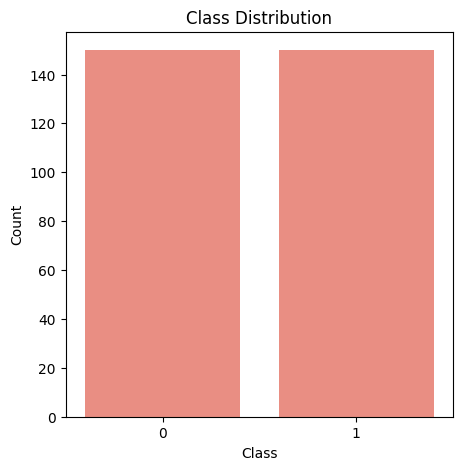

Class proportions:
 label_sexist
0    0.5
1    0.5
Name: proportion, dtype: float64


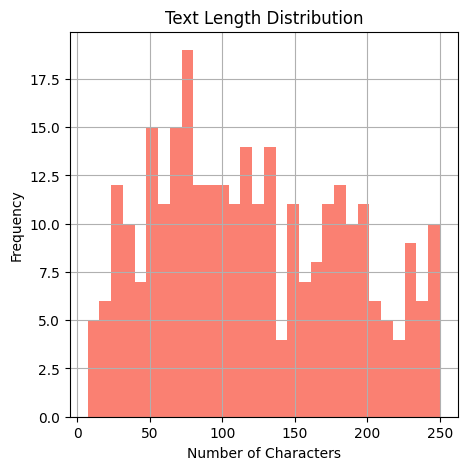

count    300.000000
mean     120.926667
std       64.839715
min        7.000000
25%       66.000000
50%      114.500000
75%      176.250000
max      250.000000
Name: text_length, dtype: float64


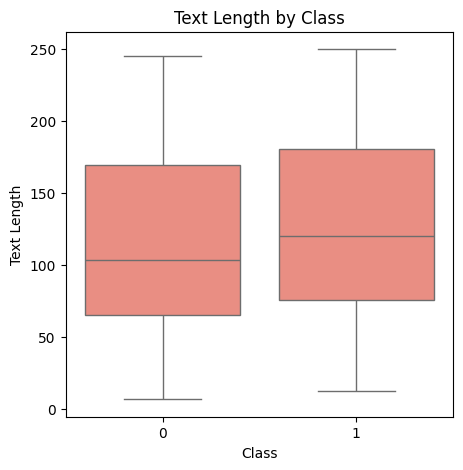

In [9]:
a2_test_data = pd.read_csv(data_file_path)
a2_test_data[label] = a2_test_data[label].map(label_mapping)
dataset_overview(a2_test_data[[text,label]])
text_length_analysis(a2_test_data[[text,label]])

,text,label_sexist
0,I would never have my kid go to a daycare with...,0
1,Democrat women are so butt fucking ugly.,1
2,If you really wanted to twist the knife you’d ...,0
3,Those women are pro-rape. They didn’t care abo...,1
4,Married a bitch... Is it the standard scenario...,1




Dataset contains 1000 rows and 2 columns.


Missing values:
 text            0
label_sexist    0
dtype: int64


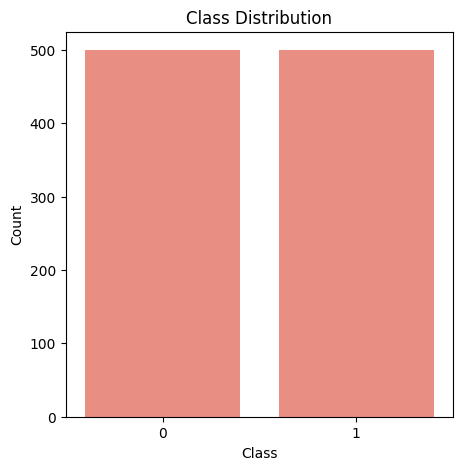

Class proportions:
 label_sexist
0    0.5
1    0.5
Name: proportion, dtype: float64


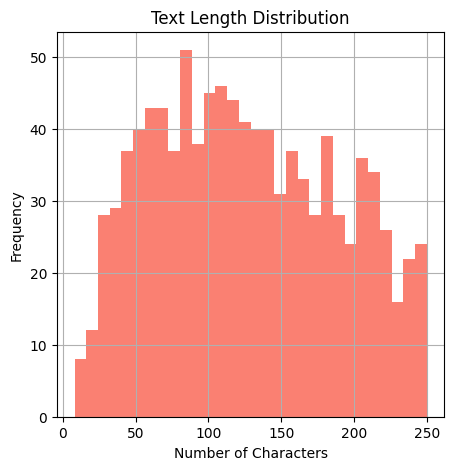

count    1000.000000
mean      126.036000
std        62.129081
min         8.000000
25%        74.000000
50%       120.000000
75%       177.000000
max       250.000000
Name: text_length, dtype: float64


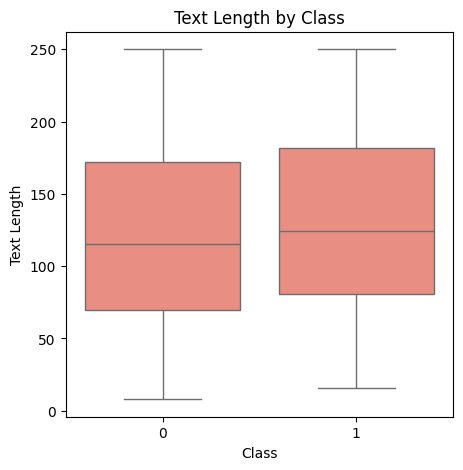

In [10]:
demonstrations = pd.read_csv(os.path.join('data', 'demonstrations.csv'))
demonstrations[label] = demonstrations[label].map(label_mapping)
dataset_overview(demonstrations[[text,label]])
text_length_analysis(demonstrations[[text,label]])

We can conclude that both datasets are free of missing data, exhibit similar distributions of word lengths per text (with comparable mean values), and are generally quite alike overall. No additional preprocessing other than the one from the transformer pipeline itself is necessary

## ⚙️ Helper functions

In [11]:
prompt_zero_shot_template = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        TEXT:
        {text}

        ANSWER:
        """
    }
]

prompt_few_shot_template = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        {examples}

        TEXT:
        {text}

        ANSWER:
        """
    }
]

In [12]:
def prepare_prompts(texts, prompt_template, tokenizer, demonstrations=None, print_prompt_before_tokenization=False,**kwargs):
    """
    This function formats input text samples into instruction prompts.

    Inputs:
      texts: list of input texts to classify via prompting
      prompt_template: the prompt template provided in this assignment
      tokenizer: the transformers Tokenizer object instance associated with the chosen model card
      demonstrations: example text-sentiment pairs for the demonstrations

    Outputs:
      List of tokenized inputs, formatted into instruction prompts
    """
    formatted_prompts = []

    for text in texts:
        # Replace placeholder in prompt_template with actual text
        if demonstrations:
          prompt = prompt_template.format(text=text,examples=demonstrations)
        else:
          prompt = prompt_template.format(text=text)

        if print_prompt_before_tokenization:
          print(prompt)

        # Tokenize the formatted prompt using the provided tokenizer
        tokenized_prompt = tokenizer(prompt,return_tensors='pt').to(model.device)

        # Append the tokenized prompt to the list
        formatted_prompts.append(tokenized_prompt)

    return formatted_prompts


def generate_responses(model, prompt_examples, tokenizer, generation_config, temperature = None,**kwargs):
    """
    This function implements the inference loop for an LLM model.
    Given a set of examples, the model is tasked to generate a response.

    Inputs:
      model: LLM model instance for prompting
      prompt_examples: list of pre-processed text samples (tokenized prompts)
      tokenizer: Huggingface tokenizer instance
      generation_config: configuration for model generation

    Outputs:
      generated responses: list of model outputs
    """
    responses = []

    # Iterate over each prompt example and generate a response
    print(f'---Temperature is set to {temperature}')
    for example in prompt_examples:
        # Generate the response using the model
        if generation_config.temperature is None:
          generated = model.generate(input_ids=example['input_ids'].to(model.device),
                                    attention_mask=example['attention_mask'].to(model.device),
                                    generation_config=generation_config,
                                    do_sample=False)
        else:
          generated = model.generate(input_ids=example['input_ids'].to(model.device),
                                    attention_mask=example['attention_mask'].to(model.device),
                                    generation_config=generation_config,
                                    do_sample=True,
                                    temperature=temperature)


        # Decode the output response
        output = tokenizer.batch_decode(generated, skip_special_tokens=True)[0]

        # Store the response
        responses.append(output)

    return responses


def process_response(response,**kwargs):
    """
    This function takes a textual response generated by the LLM
    and processes it to map the response to a binary label.

    Inputs:
      response: generated response from LLM

    Outputs:
      parsed binary response: return 1 if YES and 0 if NO
    """
    # Assume that the model's response will either be "YES" or "NO" (you can adjust based on model output)

    if """ANSWER:
         YES""" in response or """[/INST] YES""" in response:
        return 1
    elif """ANSWER:
         NO""" in response or  """[/INST] NO""" in response:
        return 0
    else:
        return None  # If the response is neither YES nor NO, return None or handle appropriately

def compute_metrics(processed_responses, y_true):
    """
    This function takes predicted and ground-truth labels and computes metrics.
    In particular, it computes accuracy and fail-ratio metrics.
    This function internally invokes `process_response` to process the responses.

    Inputs:
      responses: list of generated LLM responses (strings)
      y_true: list or numpy array of ground-truth binary labels (0 or 1)

    Outputs:
      dictionary containing desired metrics: accuracy and fail-ratio
    """

    # Convert processed responses to numpy arrays for easy comparison
    processed_responses = np.array(processed_responses)
    y_true = np.array(y_true)

    # Calculate accuracy: Percentage of correct predictions
    correct_predictions = np.sum(processed_responses == y_true)
    total_predictions = len(processed_responses)
    accuracy = correct_predictions / total_predictions

    # Calculate fail-ratio: The ratio of failed responses (responses that do not answer in YES/NO)
    failed_responses = np.sum(processed_responses == 0)  # Consider 0 as failure for a "NO" answer
    fail_ratio = failed_responses / total_predictions

    return {
        "accuracy": accuracy,
        "fail-ratio": fail_ratio
    }



In [13]:
def inference_pipeline(texts, true_labels, prompt, tokenizer, model, generation_config, demonstrations = None, print_execution_time=True, print_metrics = True,  **kwargs):
    start_time = time.time()  # Record the start time
    # Prepare prompts
    prepared_prompts = prepare_prompts(texts, prompt, tokenizer, demonstrations, **kwargs)

    # Run inference
    generated_responses = generate_responses(model, prepared_prompts, tokenizer, generation_config, **kwargs)

    # Process the generated responses
    processed_responses = [process_response(response) for response in generated_responses]

    # Compute and output metrics
    metrics = compute_metrics(processed_responses, true_labels)
    if print_metrics:
      print(metrics)

    if print_execution_time:
      end_time = time.time()  # Record the end time
      execution_time = end_time - start_time  # Calculate the execution time
      print(f"Execution time: {execution_time:.6f} seconds")
    return processed_responses, metrics

In [14]:
def build_few_shot_demonstrations(demonstrations, label_column=label, text_column=text, num_per_class=2):
    """
    Inputs:
      demonstrations: the pandas.DataFrame object containing the demonstrations dataset.
      label_column: the column name in the DataFrame representing the labels (e.g., 'label_sexist').
      text_column: the column name in the DataFrame representing the text (e.g., 'text').
      num_per_class: number of demonstrations per class.

    Outputs:
      a string of formatted textual demonstrations to inject into the prompt template.
    """
    # Group the demonstrations by the label
    grouped = demonstrations.groupby(label_column)

    # Collect a few demonstrations per class
    few_shot_examples = []
    for label, group in grouped:
        # Select up to num_per_class examples per class
        examples = group.sample(n=min(num_per_class, len(group)), random_state=random.randint(0, 10000)) #you can change for a number like random_state=42

        # Format the examples
        for _, row in examples.iterrows():
            sentiment = "YES" if row[label_column] == 1 else "NO"
            formatted_example = f"TEXT: {row[text_column]}\nANSWER: {sentiment}"
            few_shot_examples.append(formatted_example)

    # Combine the formatted examples into a single string
    demonstrations_str = '\n'.join(few_shot_examples)
    return demonstrations_str


## 🤖 Mistral v3

We chose to use models with a temperature of 0 and 0.3 for this binary classification problem, as it aligns with the nature of the task and the transformer-based prompting approach. A lower temperature wasn considered, as it in an exact task like this there is no need of introducing unnecessary randomness (unlike in the generating tasks). Additionally, we followed the assignment's guidelines by testing with 2, 3, and 4 examples per prompt in the few-shot prompting setup.

[Huggingface Documentation](https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3?library=transformers)

### 0️⃣ Zero-shot

In [15]:
model_card = "mistralai/Mistral-7B-Instruct-v0.3"
data = a2_test_data.copy()
display(data.head())
predicted_labels_list_mistral = dict()

,rewire_id,text,label_sexist
0,sexism2022_english-17133,The boys must be gaming because there goes the...,0
1,sexism2022_english-14197,Look at those eyes. Either someone unexpectedl...,1
2,sexism2022_english-3018,Old man mogs everyone in this sub,0
3,sexism2022_english-5301,"Excellent, I was just looking at another post ...",0
4,sexism2022_english-17796,So you run back to daddy whenever you need hel...,1


In [16]:
tokenizer = AutoTokenizer.from_pretrained(model_card)
tokenizer.pad_token = tokenizer.eos_token
terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

data = Dataset.from_pandas(data)
prompt_zero_shot = tokenizer.apply_chat_template(prompt_zero_shot_template, tokenize=False, add_generation_prompt=True)

print("\n\n=====PROMPT TEMPLATE=====")
print(prompt_zero_shot)  # Optional: To see the generated prompt

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/141k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]



=====PROMPT TEMPLATE=====
<s>[INST] You are an annotator for sexism detection.

Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        TEXT:
        {text}

        ANSWER:
        [/INST]


In [17]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Enable 4-bit quantization
    bnb_4bit_use_double_quant=True,  # Optional: Enable double quantization for more efficiency
    bnb_4bit_quant_type="nf4",  # Use the "nf4" quantization type
    bnb_4bit_compute_dtype=torch.bfloat16,  # Optionally use bfloat16 for computation
)

model = AutoModelForCausalLM.from_pretrained(
    model_card,
    return_dict=True,
    quantization_config=bnb_config,
    device_map='auto'  # Automatically place the model on the available device (GPU or CPU)
)

generation_config = model.generation_config
generation_config.max_new_tokens = 100
generation_config.eos_token_id = tokenizer.eos_token_id
generation_config.pad_token_id = tokenizer.eos_token_id
generation_config.temperature = None
generation_config.num_return_sequences = 1

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

#### 🥶 Temperature = None

In [18]:
processed_responses, _  = inference_pipeline(list(data[text]),
                                             list(data[label]),
                                             prompt_zero_shot,
                                             tokenizer,
                                             model,
                                             generation_config)
predicted_labels_list_mistral['mistral_v3_zero_shot_temp_0'] = processed_responses

---Temperature is set to None
{'accuracy': 0.59, 'fail-ratio': 0.11}
Execution time: 387.687307 seconds


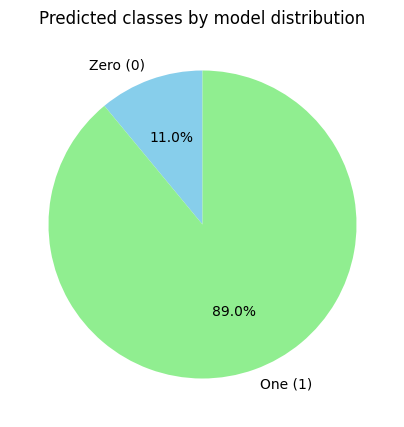

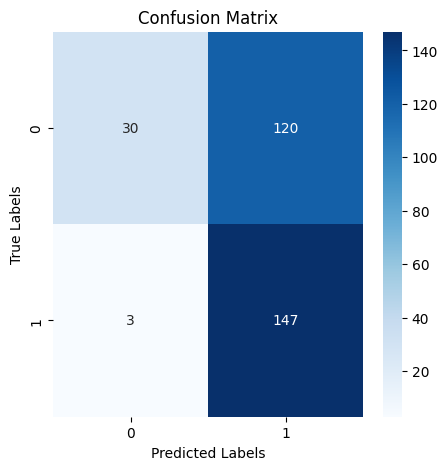

In [19]:
plot_predicted_classes_distribution(processed_responses)
get_confusion_matrix(list(data[label]),processed_responses)

#### 🥵 Temperature = 0.3

In [21]:
processed_responses, _  = inference_pipeline(list(data[text]),
                                             list(data[label]),
                                             prompt_zero_shot,
                                             tokenizer,
                                             model,
                                             generation_config,
                                             temperature = 0.3)
predicted_labels_list_mistral['mistral_v3_zero_shot_temp_03'] = processed_responses

---Temperature is set to 0.3
{'accuracy': 0.59, 'fail-ratio': 0.11}
Execution time: 401.255919 seconds


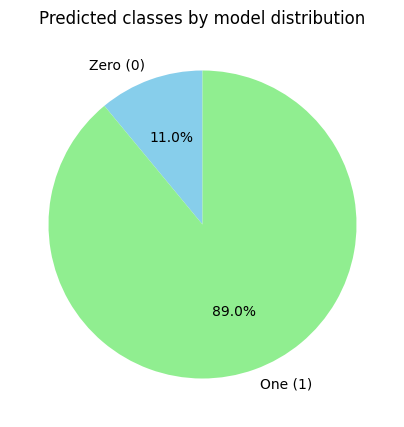

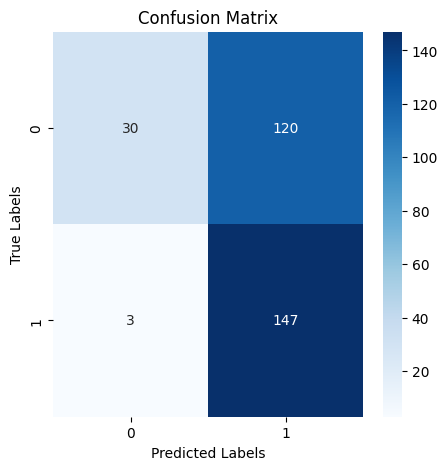

In [22]:
plot_predicted_classes_distribution(processed_responses)
get_confusion_matrix(list(data[label]),processed_responses)

The pre-trained model using zero-shot classification with both default temperature 1 and 0.3 had identical results. This suggests that the temperature had little to no influence, likely because zero-shot classification relies heavily on the model's initial pre-training, where the temperature parameter only slightly adjusts the randomness of the output—something that didn’t significantly impact this binary classification task. By examining the confusion matrix, we observe a bias towards predicting "sexism," with a high number of false positives. From this we can speculate that the model might be trained on an imbalanced dataset as it fails to recognise the other class.

### 📚 Few-shot

Examples of how build_few_shot_demonstration function works

In [23]:
print(build_few_shot_demonstrations(demonstrations))

TEXT: Germany: Muslim migrant stabs German woman to death on a Düsseldorf street. ☪️☪️☪️ More "mental illness" in Germany. At least that is what the MSM will tell us it is. SMH. #MondayMotivation #Dusseldorf [URL]
ANSWER: NO
TEXT: Besides, Chad can hit 4 chords and women will think he's a virtuoso, KEK
ANSWER: NO
TEXT: Get fucked you stupid old hag. Why dont you go protect your baby dick suckers and fuck off. Stupid degenerate trash.
ANSWER: YES
TEXT: Behind every great man is a great woman. And that's how pegging got to be popular. #GabJokes
ANSWER: YES


In [24]:
prompt_few_shot = tokenizer.apply_chat_template(prompt_few_shot_template, tokenize=False, add_generation_prompt=True)

print("\n\n=====PROMPT TEMPLATE=====")
print(prompt_few_shot)  # Optional: To see the generated prompt



=====PROMPT TEMPLATE=====
<s>[INST] You are an annotator for sexism detection.

Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        {examples}

        TEXT:
        {text}

        ANSWER:
        [/INST]


Example prompts for number of examples per class = 2,3,4

In [25]:
random_index = random.randint(0, len(data[text]) - 1)
print(f'Random chosen example text: {data[text][random_index]}')
print(f'True label: {data[label][random_index]}')
for n_class in [2,3,4]:
  print(f"\t== Number of examples per class for few-shot-learning = {n_class}")
  response, _ = inference_pipeline([data[text][random_index]], [data[label][random_index]], prompt_few_shot, tokenizer, model, generation_config,build_few_shot_demonstrations(demonstrations, num_per_class=n_class),print_execution_time= False, print_metrics=False,print_prompt_before_tokenization=True)
  print(f"Response by model: {response[0]}")

Random chosen example text: Are your chromosomes XX? If so, you're 100% female.
True label: 1
	== Number of examples per class for few-shot-learning = 2
<s>[INST] You are an annotator for sexism detection.

Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        TEXT: stupid ugly ass girlfriend soyboy cuck beta fucking stupid ass normies
ANSWER: NO
TEXT: But if she's the one who will die why should he get the vasectomy. IDK Just seems dumb
ANSWER: NO
TEXT: They should do a confidential pole on how many male divorce attorneys have slept with their female clients. Lol. And then another pole on how many thought they were telling the truth.
ANSWER: YES
TEXT: She was so miserable she couldnt leave him for 2 years, aka "he treated me like a little whore and i loved it all until he dumped me for another bitch"
ANSWER: YES

        TEXT:
        Are your chromosomes XX? If so, you're 100% female.

        ANSWER:
        [/INST]
---Te

	== Number of examples per class for few-shot-learning = 2
---Temperature is set to None
{'accuracy': 0.7733333333333333, 'fail-ratio': 0.36666666666666664}
Execution time: 900.826323 seconds


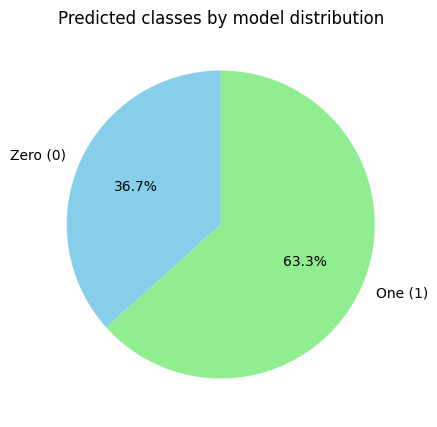

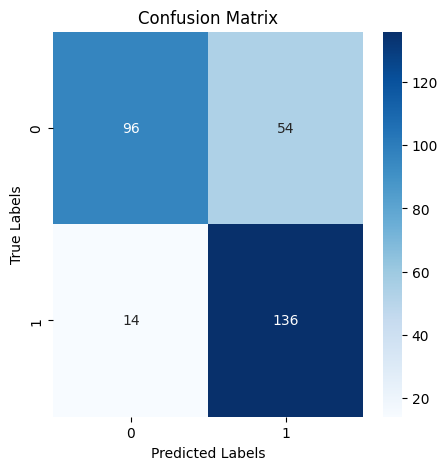

	== Number of examples per class for few-shot-learning = 3
---Temperature is set to None
{'accuracy': 0.7533333333333333, 'fail-ratio': 0.44666666666666666}
Execution time: 1195.912056 seconds


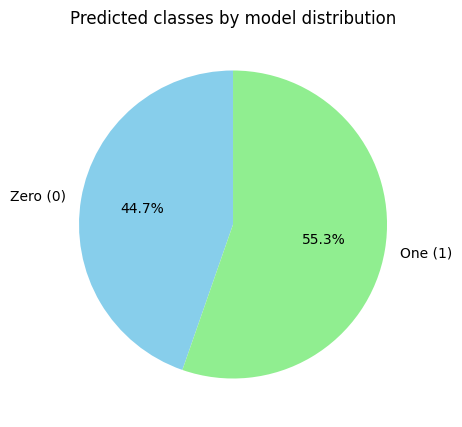

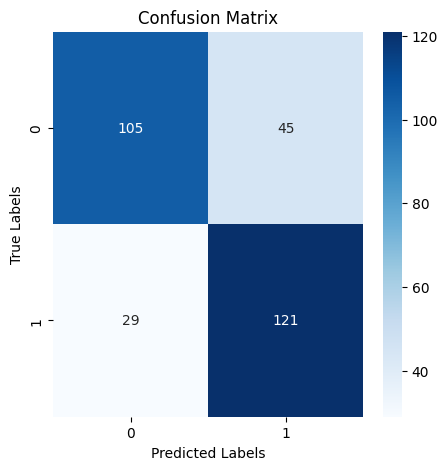

	== Number of examples per class for few-shot-learning = 4
---Temperature is set to None
{'accuracy': 0.7066666666666667, 'fail-ratio': 0.28}
Execution time: 1023.970746 seconds


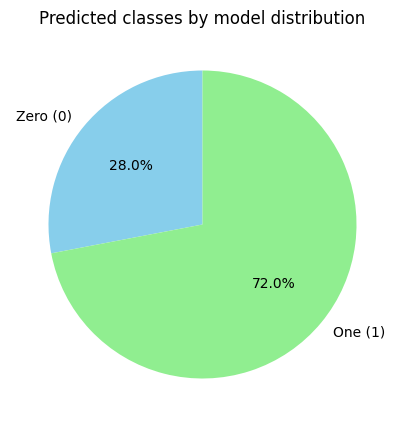

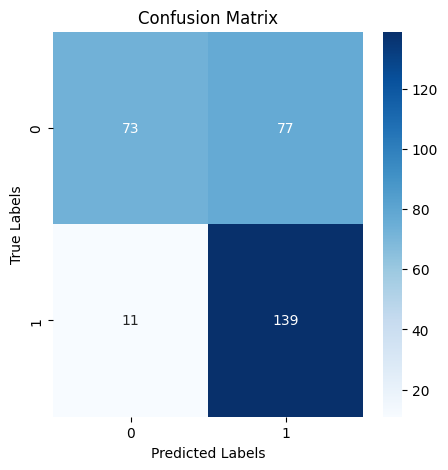

In [26]:
for n_class in [2,3,4]:
  print(f"\t== Number of examples per class for few-shot-learning = {n_class}")
  processed_responses, _  = inference_pipeline(list(data[text]), list(data[label]), prompt_few_shot, tokenizer, model, generation_config,build_few_shot_demonstrations(demonstrations, num_per_class=n_class) )
  plot_predicted_classes_distribution(processed_responses)
  get_confusion_matrix(list(data[label]),processed_responses)
  predicted_labels_list_mistral[f'mistral_v3_few_shot_n_examples_{n_class}'] = processed_responses


When switching to few-shot prompting, we observe a reduction in the bias towards the "sexist" class and more balanced predictions. This is likely due to the model being exposed to more context during the prompt, which helps it better understand the small differences between the classes. We can observe that the best results were achieved when the number of examples was set to 2.This could be because 2 examples give sufficient context for the model to generalize and avoiding overfitting to the limited examples.

In [32]:
save_dict_to_csv(predicted_labels_list_mistral, "mistral_performance_summary.csv")

## 🛸 Phi3-mini

Same as the other model.

We chose to use models with a temperature of 0 and 0.3 for this binary classification problem, as it aligns with the nature of the task and the transformer-based prompting approach. A lower temperature wasn considered, as it in an exact task like this there is no need of introducing unnecessary randomness (unlike in the generating tasks). Additionally, we followed the assignment's guidelines by testing with 2, 3, and 4 examples per prompt in the few-shot prompting setup.

[Huggingface Documentation](https://huggingface.co/microsoft/Phi-3-mini-4k-instruct)

### 0️⃣ Zero-shot

In [35]:
model_card = "microsoft/Phi-3-mini-4k-instruct"
data = a2_test_data.copy()
display(data.head())
predicted_labels_list_phi3 = dict()

,rewire_id,text,label_sexist
0,sexism2022_english-17133,The boys must be gaming because there goes the...,0
1,sexism2022_english-14197,Look at those eyes. Either someone unexpectedl...,1
2,sexism2022_english-3018,Old man mogs everyone in this sub,0
3,sexism2022_english-5301,"Excellent, I was just looking at another post ...",0
4,sexism2022_english-17796,So you run back to daddy whenever you need hel...,1


In [36]:
tokenizer = AutoTokenizer.from_pretrained(model_card)
tokenizer.pad_token = tokenizer.eos_token
terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]
data = Dataset.from_pandas(data)

prompt_zero_shot = tokenizer.apply_chat_template(prompt_zero_shot_template, tokenize=False, add_generation_prompt=True)

print("\n\n=====PROMPT TEMPLATE=====")
print(prompt_zero_shot)  # Optional: To see the generated prompt

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]



=====PROMPT TEMPLATE=====
<|system|>
You are an annotator for sexism detection.<|end|>
<|user|>
Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        TEXT:
        {text}

        ANSWER:
        <|end|>
<|assistant|>



In [37]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Enable 4-bit quantization
    bnb_4bit_use_double_quant=True,  # Optional: Enable double quantization for more efficiency
    bnb_4bit_quant_type="nf4",  # Use the "nf4" quantization type
    bnb_4bit_compute_dtype=torch.bfloat16,  # Optionally use bfloat16 for computation
)

model = AutoModelForCausalLM.from_pretrained(
    model_card,
    return_dict=True,
    quantization_config=bnb_config,
    device_map='auto'  # Automatically place the model on the available device (GPU or CPU)
)

generation_config = model.generation_config
generation_config.max_new_tokens = 100
generation_config.eos_token_id = tokenizer.eos_token_id
generation_config.pad_token_id = tokenizer.eos_token_id
generation_config.temperature = None
generation_config.num_return_sequences = 1

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

#### 🥶 Temperature = None

In [38]:
processed_responses, _  = inference_pipeline(list(data[text]),
                                             list(data[label]),
                                             prompt_zero_shot,
                                             tokenizer, model,
                                             generation_config)
predicted_labels_list_phi3['phi3_zero_shot_temp_0'] = processed_responses

---Temperature is set to None
{'accuracy': 0.64, 'fail-ratio': 0.46}
Execution time: 205.725439 seconds


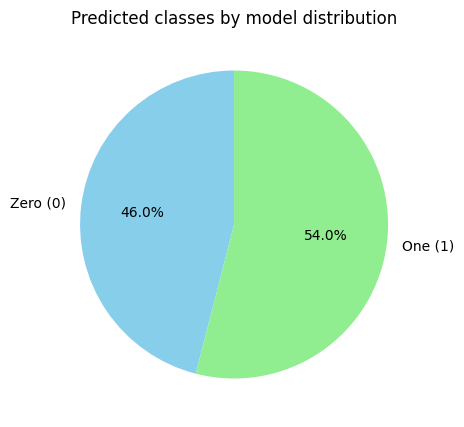

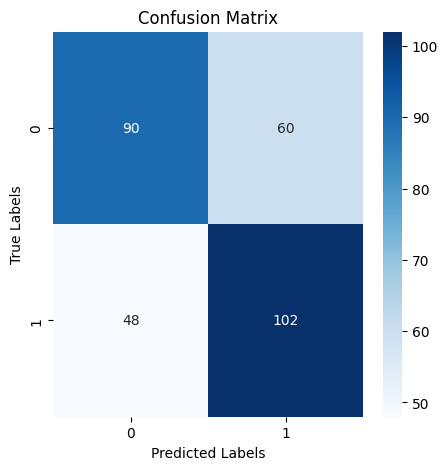

In [39]:
plot_predicted_classes_distribution(processed_responses)
get_confusion_matrix(list(data[label]),processed_responses)

#### 🥵 Temperature = 0.3

In [41]:
processed_responses, _  = inference_pipeline(list(data[text]),
                                             list(data[label]),
                                             prompt_zero_shot,
                                             tokenizer,
                                             model,
                                             generation_config,
                                             temperature=0.3)
predicted_labels_list_phi3['phi3_zero_shot_temp_03'] = processed_responses

---Temperature is set to 0.3
{'accuracy': 0.64, 'fail-ratio': 0.46}
Execution time: 214.246449 seconds


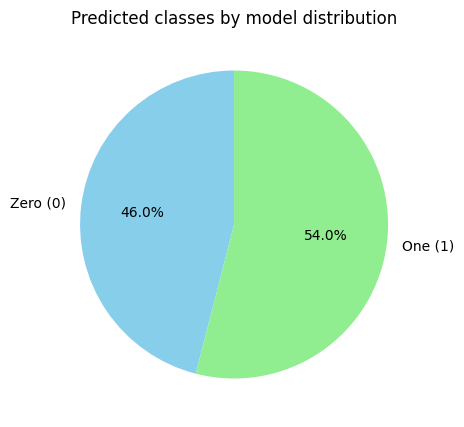

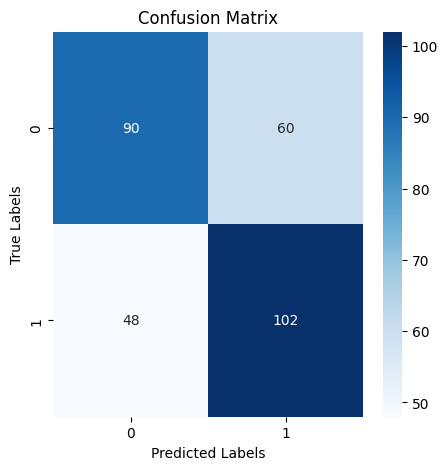

In [42]:
plot_predicted_classes_distribution(processed_responses)
get_confusion_matrix(list(data[label]),processed_responses)

Similar as in the Mistral model we can see no big influence on the temperature change, however we can conclude that the Phi3-mini model does more balanced prediction and doesn't show a strong bias unlike the Mistral model from which we can speculate a training process with a more balanced data for this task

### 📚 Few-shot

In [43]:
prompt_few_shot = tokenizer.apply_chat_template(prompt_few_shot_template, tokenize=False, add_generation_prompt=True)

print("\n\n=====PROMPT TEMPLATE=====")
print(prompt_few_shot)  # Optional: To see the generated prompt



=====PROMPT TEMPLATE=====
<|system|>
You are an annotator for sexism detection.<|end|>
<|user|>
Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        {examples}

        TEXT:
        {text}

        ANSWER:
        <|end|>
<|assistant|>



In [44]:
random_index = random.randint(0, len(data[text]) - 1)
print(f'Random chosen example text: {data[text][random_index]}')
print(f'True label: {data[label][random_index]}')
for n_class in [2,3,4]:
  print(f"\t== Number of examples per class for few-shot-learning = {n_class}")
  response, _ = inference_pipeline([data[text][random_index]], [data[label][random_index]], prompt_few_shot, tokenizer, model, generation_config,build_few_shot_demonstrations(demonstrations, num_per_class=n_class), print_execution_time= False, print_metrics=False,print_prompt_before_tokenization=True)
  print(f"Response by model: {response[0]}")

Random chosen example text: Holy fuck is this for real
True label: 0
	== Number of examples per class for few-shot-learning = 2
<|system|>
You are an annotator for sexism detection.<|end|>
<|user|>
Your task is to classify input text as containing sexism or not. Respond only YES or NO.

        EXAMPLES:
        TEXT: My mother doesn't use me for money. But my father is constantly trying to even though I don't make much money.
ANSWER: NO
TEXT: Top investment fund manager for George Soros who was featured in Liar's Poker 'ran human trafficking enterprise in which he raped, electrocuted and imprisoned women in NYC sex dungeon', lawsuit claims [URL]
ANSWER: NO
TEXT: Only a woman would get off to having sex with thugs like this who brag about it to her son. We're not claiming to be attractive to whores. Maybe if we shot up a school or raped and killed several women we'd get some fan pages on Tumblr:)
ANSWER: YES
TEXT: "If women reject me then it is because they are either fucking Chad or R

	== Number of examples per class for few-shot-learning = 2
---Temperature is set to None
{'accuracy': 0.62, 'fail-ratio': 0.6933333333333334}
Execution time: 430.457549 seconds


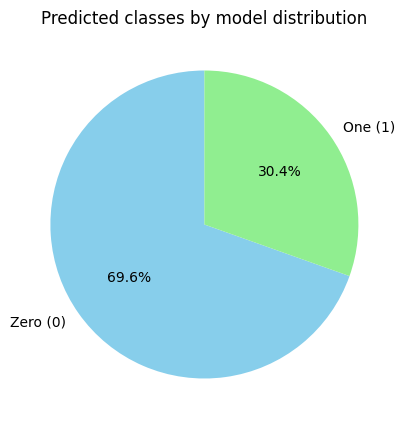

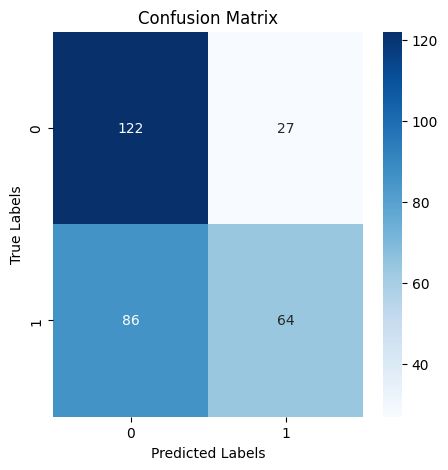

	== Number of examples per class for few-shot-learning = 3
---Temperature is set to None
{'accuracy': 0.64, 'fail-ratio': 0.5866666666666667}
Execution time: 481.353246 seconds


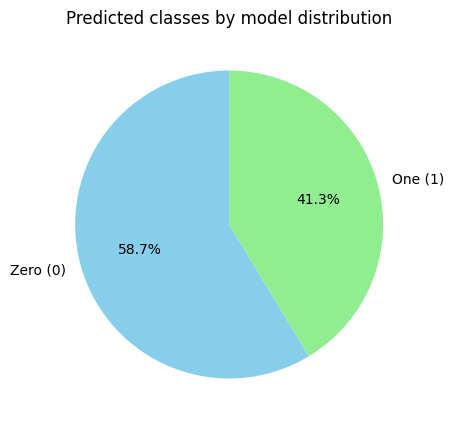

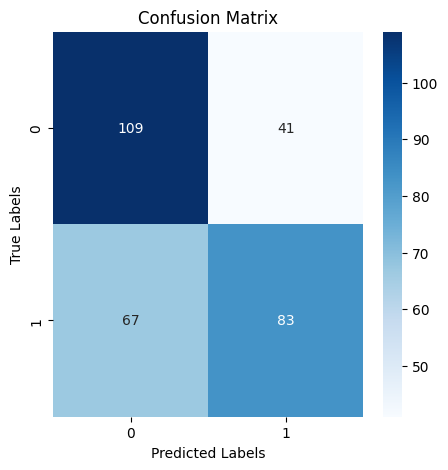

	== Number of examples per class for few-shot-learning = 4
---Temperature is set to None
{'accuracy': 0.66, 'fail-ratio': 0.5533333333333333}
Execution time: 579.713494 seconds


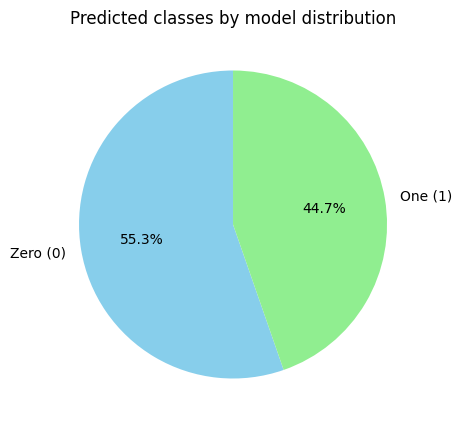

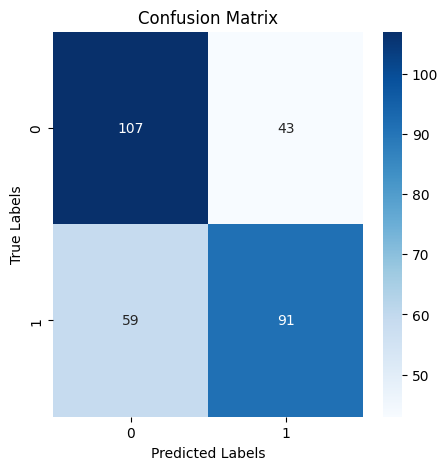

In [45]:
for n_class in [2,3,4]:
  print(f"\t== Number of examples per class for few-shot-learning = {n_class}")
  processed_responses, _  = inference_pipeline(list(data[text]), list(data[label]), prompt_few_shot, tokenizer, model, generation_config,build_few_shot_demonstrations(demonstrations, num_per_class=n_class) )
  plot_predicted_classes_distribution(processed_responses)
  get_confusion_matrix(list(data[label]),processed_responses)
  predicted_labels_list_phi3[f'phi3_few_shot_n_examples_{n_class}'] = processed_responses

In contrast to the previous Mistral model, we observe that this model shows no significant improvement when using a few-shot prompting approach. This suggests that the task might be simple enough for the pre-trained model to handle with high accuracy, meaning that adding a few examples in the prompt doesn't significantly alter its performance. Additionally, we notice a higher value for the fail-ratio making this model less reliable then the Mistral model

In [46]:
save_dict_to_csv(predicted_labels_list_phi3, "phi3_performance_summary.csv")

## 🤼‍♂️Comparison between models

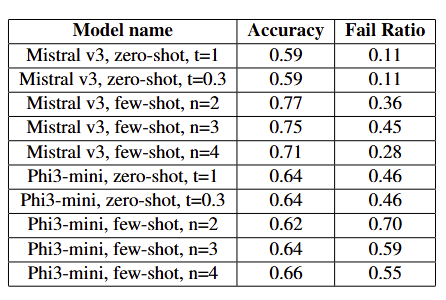

✅ **The same detailed conclusion from this reports is included in the report**.

---


> As seen in our experiments, **zero-shot prompting** is faster due to its simplicity. Since it is an
approach that doesn’t rely on labeled examples it
is easy to implement and it makes an efficient baseline. In contrast, **few-shot prompting** took more
time because it incorporates labeled examples into
the prompt, providing more task-specific context.
This added expressiveness and increased execution
times, but typically resulted in better performance,
as shown in our results. However when changing
the number of examples included in the prompt for
both models we can notice, after a certain point, the
additional examples may not add much value and
might even result in a slight decrease in accuracy.
This could be due to the model becoming too con-
strained by the prompt and the result of the model
overfitting. <br>
**When comparing the influence of the temperature parameter**, in binary decision-making tasks, a
low temperature (e.g., 0) is preferred for consistent and reliable outputs, as it reduces randomness.
Higher temperatures are better for creative tasks,
but a slightly higher temperature (e.g., 0.3) can capture subtler nuances, which is why we included it
in our experiments. The default temperature of 1.0
balances randomness and confidence in predictions,
while 0.3 sharpens the output, making the model
more confident and deterministic, often choosing
the most likely option. From the experiments ran
on both models with zero-shot-prompting we can
conclude that the temperature setting may not significantly influence the accuracy or fail ratio for this
task. Since the models are already pre-trained and
potentially capable of generalizing well, changes
in the temperature parameter don’t have a noticable
impact on the performance. It suggests that the task
may be relatively straightforward for this model,
or it could also indicate that the model is already
producing high-confidence predictions. <br>
**When comparing the models between each other**,
we observe that Mistral v3 begins with a zero-shot
approach that shows a bias toward the sexist class,
but by adding examples in a few-shot setting, it
converges to a more balanced and accurate solution. This significant improvement with few-shot
prompting is likely due to Mistral’s training on a
dataset or architecture that benefits from contextual examples. In contrast, Phi3-mini shows little
difference between few-shot and zero-shot performance, likely due to its architecture or pretraining
being less responsive to contextual examples. Although Phi3-mini maintains a relatively consistent
accuracy that is not far behind Mistral, it exhibits
a higher fail ratio, indicating less reliability in predictions across scenarios.





### ⚙️Utils

In [53]:
def get_misclassified_indices(true_labels, predictions_list, models):
    """
    Get the indices of misclassified samples for each model and the indices where all models failed.

    Args:
        true_labels (list): The true labels of the dataset.
        predictions_list (list of lists): A list of predicted labels from multiple models.
        models (list): A list of model names

    Returns:
        dict: A dictionary where keys are model indices (e.g., 'Model 1') and values are lists of misclassified indices.
        list: A list of indices where all models failed to predict correctly.
    """
    # Convert to numpy arrays for easier operations
    true_labels = np.array(true_labels)
    predictions_list = np.array(predictions_list)  # Shape: (num_models, num_samples)

    misclassified_indices = {}
    title_section = f"""
    <footer style="text-align: center; margin-top: 20px; font-size: 14px; font-weight: bold; color: #999;">
        Summary report!🚀
    </footer>
    """
    display(HTML(title_section))

    # For each model, find the misclassified indices
    for model_idx, predictions in enumerate(predictions_list):
        misclassified = np.where(predictions != true_labels)[0]  # Indices where predictions don't match
        misclassified_indices[f"Model {model_idx + 1}"] = misclassified.tolist()

        # Print the misclassified indices for the current model
        print(f"Misclassified indices for Model {models[model_idx]}: (total number = {len(misclassified.tolist())})")
        print("\t\t", end='')
        print(misclassified.tolist())

    # Find the indices where all models got it wrong
    correct_predictions = predictions_list == true_labels  # Shape: (num_models, num_samples)
    none_correct = ~np.any(correct_predictions, axis=0)  # True where no model is correct
    all_failed_indices = np.where(none_correct)[0].tolist()

    print(f"Indices where all of selected models failed: (total number = {len(all_failed_indices)})")
    print("\t\t", end='')
    print(all_failed_indices)

    return misclassified_indices, all_failed_indices

def print_index_details(idx, data, true_labels, predictions_list):
    """
    Print the true label and predictions for a given index in a formatted way.

    Args:
        idx (int): The index of the sample to analyze.
        data (pandas df): The dataset containing all the text samples
        true_labels (list): The true labels of the dataset.
        predictions_list (list of lists): A list of predicted labels from multiple models.
    """
    # Define the label formatting function
    def format_label(value):
        return "SEXIST" if value == 1 else "NOT SEXIST"

    # Print text
    print('\n\n==========🗟TEXT🗟==========')
    print(list(data['text'])[idx])
    print('=========================\n\n')

    # Get the true label and predictions for the given index
    true_label = format_label(true_labels[idx])
    print(f"Index {idx}:")
    if true_label == 'NOT SEXIST':
        print_color_bubble(f"   TRUE: ",true_label,'#28a745')
    else:
        print_color_bubble(f"  TRUE: ",true_label,'#dc3545')

    for model_idx, predictions in enumerate(predictions_list):
        model_prediction = format_label(predictions[idx])
        if model_prediction == 'NOT SEXIST':
          print_color_bubble(f"  Model {model_idx + 1}: ",model_prediction,'#28a745')
        else:
          print_color_bubble(f"  Model {model_idx + 1}: ",model_prediction,'#dc3545')


def print_color_bubble(before_text, inside_text, color="#28a745"):
    """
    Print before_text outside the bubble and inside_text inside a bubble, both on the same line in Google Colab.

    Args:
        inside_text (str): The text to display inside the bubble.
        before_text (str): The unformatted text to display outside the bubble.
        color (str): The background color of the bubble (default is green).
    """
    # Display the unformatted text (text2) and text inside the bubble in the same line
    display(HTML(f"""
        <span style="display: inline-block; font-size: 12px;">
            {before_text}
        </span>
        <div style="background-color: {color}; color: white; padding: 8px 16px;
                    border-radius: 15px; font-size: 12px; display: inline-block; vertical-align: middle;">
            {inside_text}
        </div>
    """))

In [51]:
def interactive_model_comparison(model_options, model_predictions):
    """
      Creates an interactive widget interface that allows users to select multiple models and visualize
      additional information such as confusion matrices and misclassified indices. Users can select the
      models they want to compare, input a text by its index number, and view relevant visualizations.

      Args:
          model_options (list of str): A list of available model names to select from.
          model_predictions (list of list): A list of predictions for each model, corresponding to the models
                                            in `model_options`. Each entry should contain a list of predictions.
    """
    instructions = widgets.Label(value="Select the models you want to include and the additional visualizations:")
    display(instructions)

    # Define options for the checkboxes
    options = model_options + ["(visualization) Confusion Matrix alert! 🚨 Click here!"]

    # Create a checkbox for each option
    checkboxes = [widgets.Checkbox(value=False, description=opt, layout=widgets.Layout(width='auto')) for opt in options]

    # Create an input box (hidden initially)
    input_box = widgets.Text(description="Got a text? Pick it by its index number! 👉", placeholder="Type something...")
    input_box.layout.display = "none"  # Hide the input box initially

    # Create a button to confirm the selection
    button = widgets.Button(description="Next")

    # Create a second button to submit input
    submit_button = widgets.Button(description="Ready, set, submit!")
    submit_button.layout.display = "none"  # Hide the submit button initially

    # Output widget to display the selected options and input text
    output = widgets.Output()

    # Function to show the input box when the button is clicked
    def show_input_box(b):
        selected = [cb.description for cb in checkboxes if cb.value]
        selected_indices = [model_options.index(model) for model in selected if model in model_options]
        filtered_predictions = [model_predictions[idx] for idx in selected_indices]
        input_box.layout.display = "block"  # Show the input box
        submit_button.layout.display = "block"  # Show the submit button
        get_misclassified_indices(true_labels, filtered_predictions, selected)
        if "(visualization) Confusion Matrix alert! 🚨 Click here!" in selected:
          compare_confusion_matrices(true_labels, filtered_predictions)

    # Function to handle input submission
    def on_input_submit(b):
        user_input = input_box.value  # Get the text from the input box
        with output:
            output.clear_output()  # Clear previous output
            print("Selected index:", user_input)
            print_index_details(int(user_input),data, true_labels, model_predictions)


    # Attach button click events to the respective functions
    button.on_click(show_input_box)
    submit_button.on_click(on_input_submit)

    # Display the checkboxes, button, input box, submit button, and output
    display(*checkboxes, button, input_box, submit_button, output)

### 🎯Interactive Model Comparison for Better Error Analysis

To enhance error analysis and provide a clearer and more straightforward way to compare two or more models, we created an **interactive function**. Here’s how it works:

- **Select Models**: Use the checkboxes to choose the models you want to compare.  
- **Confusion Matrix Option**: Don’t forget to select the "Confusion Matrix" option if you’d like to see the confusion matrix graphs displayed side by side for the selected models.  
- **Detailed Report**: After making your selections, you’ll get a report that includes:  
  - The **number and indices of misclassified samples** for each selected model.  
  - An input field where you can enter an index to retrieve:  
    - The **text** associated with that index.  
    - The **true label** and the **predictions** made by the selected models.  

We believe this interactive approach makes it easier to directly compare models and efficiently access "troubled" texts, providing valuable insights into their performance.

-- it may be better to rerun the cell if you want to try with other selected models


In [21]:
predicted_mistral_labels_from_file = pd.read_csv("mistral_performance_summary.csv")
predicted_phi3_labels_from_file = pd.read_csv("phi3_performance_summary.csv")
true_labels = list(data[label])
display(predicted_mistral_labels_from_file)
display(predicted_phi3_labels_from_file)
print(true_labels)

,Key,Column 1,Column 2,Column 3,Column 4,Column 5,Column 6,Column 7,Column 8,Column 9,...,Column 291,Column 292,Column 293,Column 294,Column 295,Column 296,Column 297,Column 298,Column 299,Column 300
0,mistral_v3_zero_shot_temp_0,1,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
1,mistral_v3_zero_shot_temp_03,1,1,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
2,mistral_v3_few_shot_n_examples_2,0,1,0,1,1,1,1,0,0,...,1,1,0,1,0,1,0,0,1,1
3,mistral_v3_few_shot_n_examples_3,0,1,0,1,1,1,0,0,0,...,1,0,0,1,0,1,0,0,1,1
4,mistral_v3_few_shot_n_examples_4,0,1,0,1,1,1,1,0,0,...,1,1,0,1,1,1,0,1,1,1


,Key,Column 1,Column 2,Column 3,Column 4,Column 5,Column 6,Column 7,Column 8,Column 9,...,Column 291,Column 292,Column 293,Column 294,Column 295,Column 296,Column 297,Column 298,Column 299,Column 300
0,phi3_zero_shot_temp_0,0,1,1,1,1,0,0,0,0,...,1,1,1,1,1,0,0,1,0,1
1,phi3_zero_shot_temp_03,0,1,1,1,1,0,0,0,0,...,1,1,1,1,1,0,0,1,0,1
2,phi3_few_shot_n_examples_2,0,1,0,1,1,0,0,0,0,...,1,0,0,1,0,1,0,0,0,1
3,phi3_few_shot_n_examples_3,0,1,0,1,1,0,1,0,0,...,1,0,0,1,0,1,0,1,0,1
4,phi3_few_shot_n_examples_4,0,1,0,1,1,0,1,0,0,...,1,0,0,1,0,1,0,0,0,1


[0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1]


In [ ]:
model_options = list(predicted_mistral_labels_from_file['Key']) + list(predicted_phi3_labels_from_file['Key'])
only_model_predictions_df = pd.concat([predicted_mistral_labels_from_file,predicted_phi3_labels_from_file],ignore_index=True).drop(columns=['Key'], errors='ignore')
model_predictions = only_model_predictions_df.values.tolist()

Label(value='Select the models you want to include and the additional visualizations:')

Checkbox(value=False, description='mistral_v3_zero_shot_temp_0', layout=Layout(width='auto'))

Checkbox(value=False, description='mistral_v3_zero_shot_temp_03', layout=Layout(width='auto'))

Checkbox(value=False, description='mistral_v3_few_shot_n_examples_2', layout=Layout(width='auto'))

Checkbox(value=False, description='mistral_v3_few_shot_n_examples_3', layout=Layout(width='auto'))

...

Button(description='Next', style=ButtonStyle())

Text(value='', description='Got a text? Pick it by its index number! 👉', layout=Layout(display='none'), placeh…

Button(description='Ready, set, submit!', layout=Layout(display='none'), style=ButtonStyle())

Output()

Misclassified indices for Model mistral_v3_zero_shot_temp_0: (total number = 123)
		[0, 2, 3, 6, 7, 8, 10, 15, 17, 26, 27, 32, 34, 38, 44, 46, 47, 48, 52, 53, 54, 57, 58, 60, 61, 64, 65, 67, 71, 72, 74, 81, 84, 85, 89, 90, 91, 94, 97, 100, 101, 102, 107, 108, 114, 115, 117, 119, 120, 121, 122, 123, 125, 126, 130, 133, 136, 137, 138, 140, 141, 143, 146, 147, 149, 152, 158, 159, 161, 162, 164, 165, 168, 171, 172, 177, 178, 179, 181, 186, 187, 190, 191, 192, 193, 195, 196, 199, 200, 206, 209, 211, 215, 219, 224, 226, 229, 231, 232, 233, 235, 236, 248, 253, 254, 255, 257, 262, 265, 270, 271, 274, 277, 278, 282, 283, 286, 292, 294, 295, 296, 297, 298]
Misclassified indices for Model mistral_v3_zero_shot_temp_03: (total number = 123)
		[0, 2, 3, 6, 7, 8, 10, 15, 17, 26, 27, 32, 34, 38, 44, 46, 47, 48, 52, 53, 54, 57, 58, 60, 61, 64, 65, 67, 71, 72, 74, 81, 84, 85, 89, 90, 91, 94, 97, 100, 101, 102, 107, 108, 114, 115, 117, 119, 120, 121, 122, 123, 125, 126, 130, 133, 136, 137, 138, 140, 141,

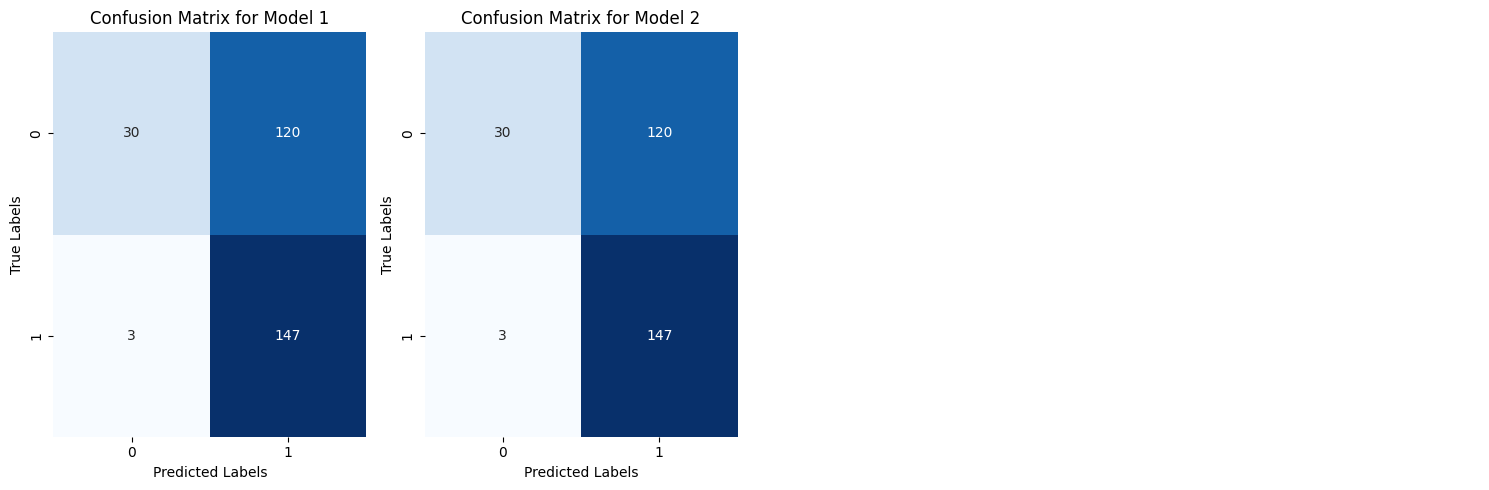

In [54]:
interactive_model_comparison(model_options, model_predictions)